> **Positionnement dans le mémoire — ÉTAT DE L'ART**  
> Ce notebook utilise KMeans et DBSCAN pour découvrir des profils d'utilisateurs. C'est une approche présente dans la littérature sur la segmentation comportementale. Limite : KMeans suppose des clusters sphériques de taille similaire (hypothèse de variance homogène). Plus fondamentalement, le clustering ne permet pas de distinguer entre "grand utilisateur peu sensible" et "petit utilisateur très sensible" — deux profils de risque réel très différents que notre STSI (notebook 10) permettra de séparer.

# Notebook 7 — Classification Non Supervisée

Objectif : découvrir des **profils d'utilisateurs** naturels dans les données, sans utiliser d'étiquette prédéfinie.

**Outils :** Scikit-learn (KMeans, DBSCAN, PCA)

---
### Pourquoi le clustering ?
On ne sait pas à l'avance combien de types d'utilisateurs existent. Le clustering laisse les données parler d'elles-mêmes et peut révéler des groupes à risque (ex : grands utilisateurs + dormeurs courts + stress élevé).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset : 15,000 lignes × 45 colonnes


## 1. Sélection des features pour le clustering

On choisit les variables les plus représentatives du comportement numérique et du bien-être. On exclut les identifiants et colonnes catégorielles textuelles.

In [2]:
CLUSTER_FEATURES = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score',
    'digital_load_hours',
    'stress_fatigue_index',
    'wellness_score',
]

df_cluster = df[CLUSTER_FEATURES].dropna()

# Standardisation OBLIGATOIRE pour le clustering
# Sans ça, les variables à grande échelle (ex: notifications) dominent la distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f'Matrice de clustering : {X_scaled.shape[0]:,} observations × {X_scaled.shape[1]} features')
print(f'Toutes les features sont maintenant centrées (moyenne=0) et réduites (std=1)')

Matrice de clustering : 15,000 observations × 12 features
Toutes les features sont maintenant centrées (moyenne=0) et réduites (std=1)


## 2. Réduction de dimension — PCA

Avant le clustering, on réduit les dimensions à 2 pour **visualiser** les regroupements. La PCA cherche les axes de variance maximale.

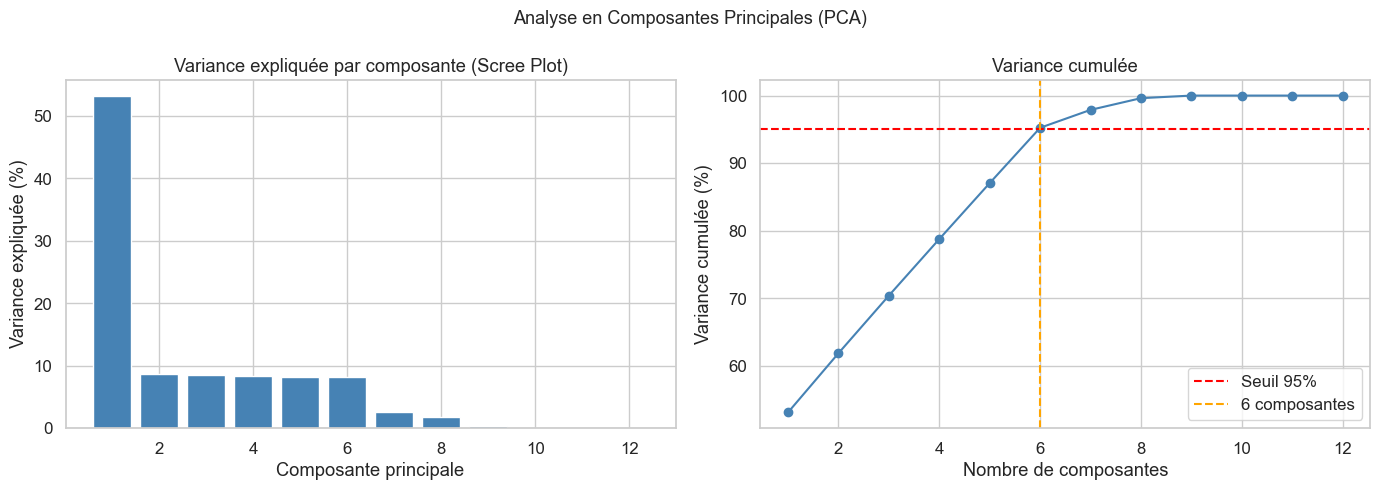

Composantes pour 95% de variance : 6
PC1 + PC2 expliquent : 61.9% de la variance


In [3]:
# PCA complète : variance expliquée par chaque composante
pca_full = PCA().fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée par composante
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Variance expliquée par composante (Scree Plot)')

# Variance cumulée
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'o-', color='steelblue')
axes[1].axhline(95, color='red', linestyle='--', label='Seuil 95%')
axes[1].axvline(n_components_95, color='orange', linestyle='--', label=f'{n_components_95} composantes')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée')
axes[1].legend()

plt.suptitle('Analyse en Composantes Principales (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Composantes pour 95% de variance : {n_components_95}')
print(f'PC1 + PC2 expliquent : {cumulative_var[1]*100:.1f}% de la variance')

PC1 explique : 53.1%
PC2 explique : 8.8%


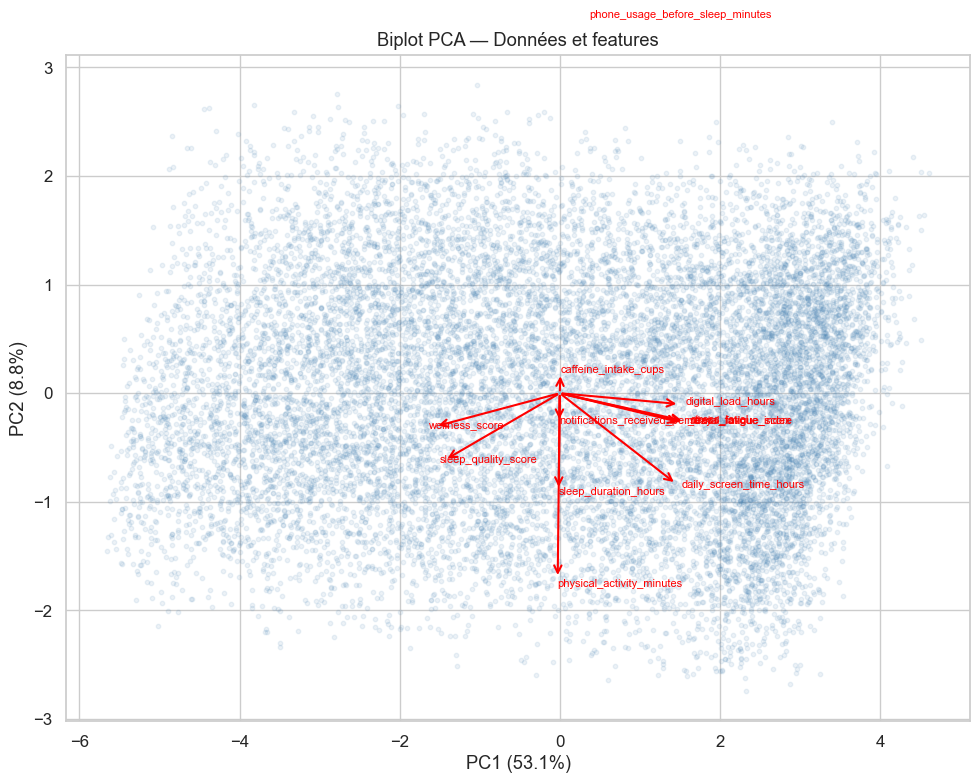

In [4]:
# PCA 2D pour visualisation
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f'PC1 explique : {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explique : {pca_2d.explained_variance_ratio_[1]*100:.1f}%')

# Biplot : loadings des variables
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.1, s=10, color='steelblue')

# Flèches des features
for i, feat in enumerate(CLUSTER_FEATURES):
    ax.annotate('', xy=(pca_2d.components_[0, i]*4, pca_2d.components_[1, i]*4),
                xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(pca_2d.components_[0, i]*4.2, pca_2d.components_[1, i]*4.2, feat, fontsize=8, color='red')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot PCA — Données et features')
plt.tight_layout()
plt.show()

## 3. KMeans — Choix du nombre de clusters

KMeans regroupe les observations en **K groupes** en minimisant la variance intra-cluster. On doit choisir K a priori.

**Méthodes pour choisir K :**
- **Elbow method** : inertie (WCSS) en fonction de K
- **Silhouette score** : mesure la qualité de la séparation
- **Score de Calinski-Harabasz** : rapport variance inter / intra

  k=2  inertie=107609.4  silhouette=0.3311  CH=10089.4
  k=3  inertie=94674.7  silhouette=0.1977  CH=6758.0
  k=4  inertie=89041.5  silhouette=0.1503  CH=5106.3
  k=5  inertie=85121.8  silhouette=0.1278  CH=4178.4
  k=6  inertie=81286.5  silhouette=0.1238  CH=3641.7
  k=7  inertie=78525.3  silhouette=0.1161  CH=3229.1
  k=8  inertie=75995.6  silhouette=0.1151  CH=2931.1
  k=9  inertie=73945.6  silhouette=0.1086  CH=2687.6
  k=10  inertie=71874.9  silhouette=0.1136  CH=2505.6


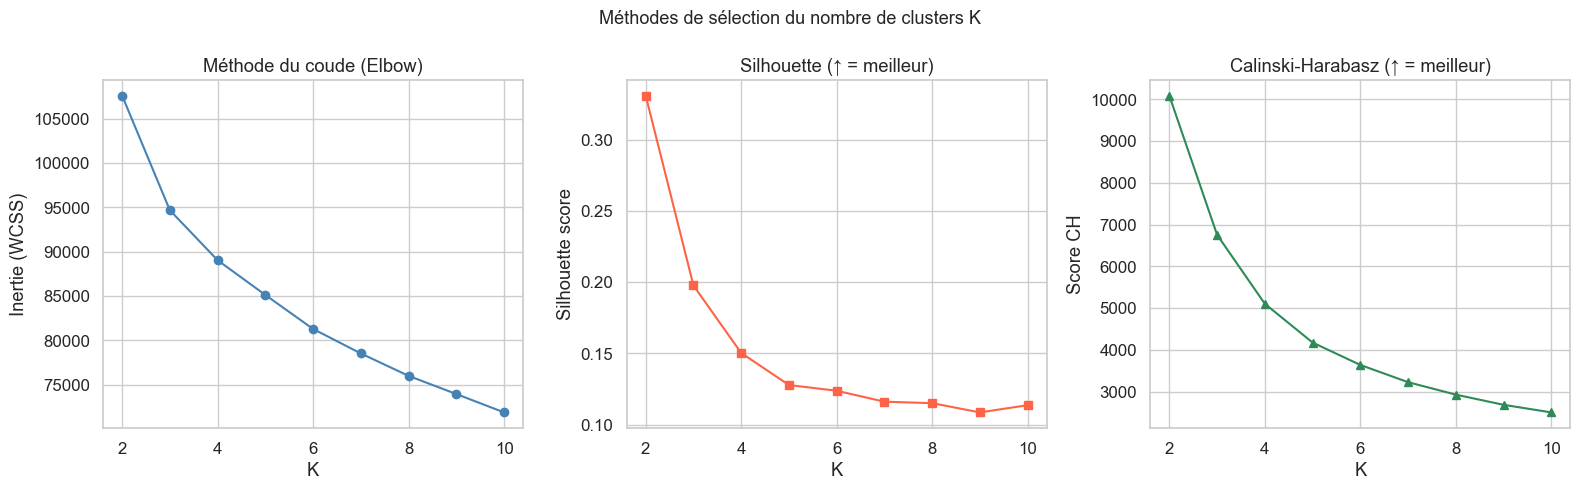

In [5]:
K_range = range(2, 11)
inertias, silhouettes, ch_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=3000))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f'  k={k}  inertie={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}  CH={ch_scores[-1]:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title('Méthode du coude (Elbow)')

axes[1].plot(K_range, silhouettes, 's-', color='tomato')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette (↑ = meilleur)')

axes[2].plot(K_range, ch_scores, '^-', color='seagreen')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score CH')
axes[2].set_title('Calinski-Harabasz (↑ = meilleur)')

plt.suptitle('Méthodes de sélection du nombre de clusters K', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# KMeans avec le K optimal identifié (adapter selon les graphiques ci-dessus)
K_OPTIMAL = 4  # À ajuster selon vos résultats

kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=20, random_state=42)
df_cluster['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print(f'KMeans avec k={K_OPTIMAL}')
print(f'\nRépartition des clusters :')
print(df_cluster['cluster_kmeans'].value_counts().sort_index())

print(f'\nSilhouette score final : {silhouette_score(X_scaled, df_cluster["cluster_kmeans"], sample_size=3000):.4f}')

KMeans avec k=4

Répartition des clusters :
cluster_kmeans
0    3769
1    3159
2    3695
3    4377
Name: count, dtype: int64

Silhouette score final : 0.1486


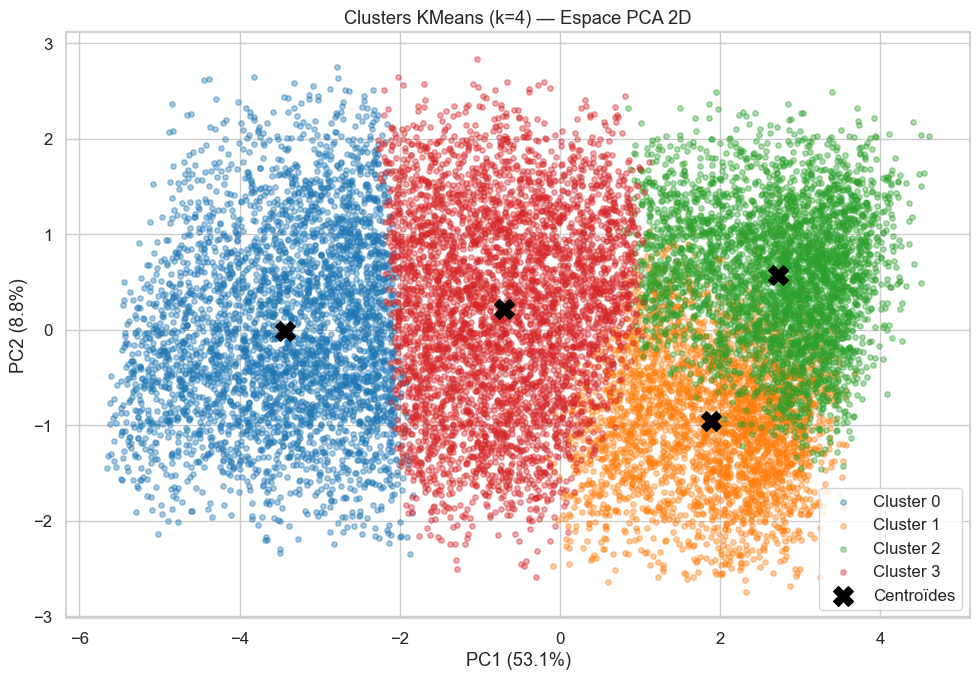

In [13]:
# Visualisation des clusters dans l'espace PCA 2D
palette = sns.color_palette('tab10', K_OPTIMAL)

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(K_OPTIMAL):
    mask = df_cluster['cluster_kmeans'] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[k]], label=f'Cluster {k}',
               alpha=0.4, s=15)

# Centroïdes dans l'espace PCA
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X',
           s=200, zorder=10, label='Centroïdes')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Clusters KMeans (k={K_OPTIMAL}) — Espace PCA 2D')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Profilage des clusters

On interprète chaque cluster en analysant les **moyennes de chaque variable** par groupe.

Profil moyen par cluster :
                daily_screen_time_hours  phone_usage_before_sleep_minutes  sleep_duration_hours  sleep_quality_score  stress_level  caffeine_intake_cups  physical_activity_minutes  notifications_received_per_day  mental_fatigue_score  digital_load_hours  stress_fatigue_index  wellness_score
cluster_kmeans                                                                                                                                                                                                                                                                                     
0                                 2.451                            48.875                 6.530                8.254         3.184                 2.013                     60.429                         161.943                 3.142               3.265                 3.163           6.078
1                                 7.806                            30.743                 6.504  

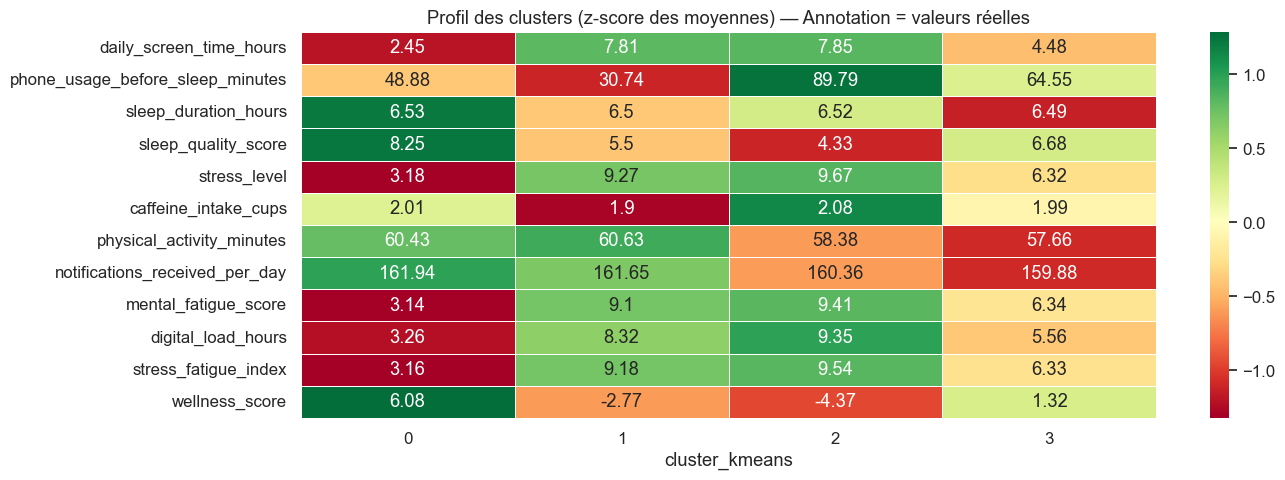

In [8]:
# Moyennes par cluster (non standardisées pour l'interprétation)
profile = df_cluster.groupby('cluster_kmeans')[CLUSTER_FEATURES].mean().round(3)

print('Profil moyen par cluster :')
print(profile.to_string())

# Heatmap des z-scores par cluster (plus facile à comparer)
profile_z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(profile_z.T, annot=profile.T.round(2), fmt='g', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Profil des clusters (z-score des moyennes) — Annotation = valeurs réelles')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

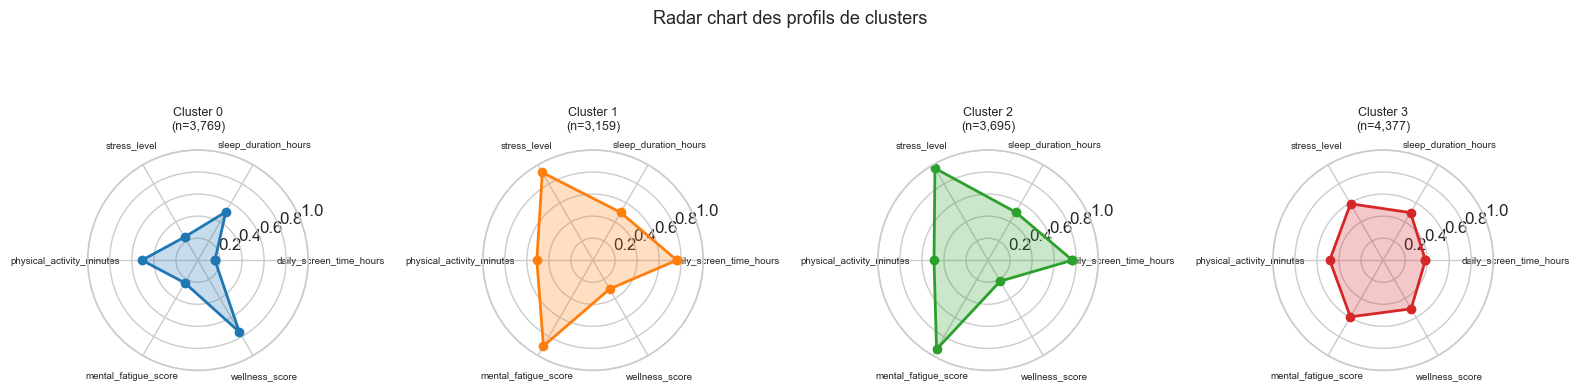

In [9]:
# Radar chart pour chaque cluster
from matplotlib.patches import FancyArrowPatch

# Variables pour le radar
radar_vars = ['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level',
               'physical_activity_minutes', 'mental_fatigue_score', 'wellness_score']

# Normalisation 0-1 pour le radar
profile_norm = (profile[radar_vars] - df_cluster[radar_vars].min()) / \
               (df_cluster[radar_vars].max() - df_cluster[radar_vars].min())

N = len(radar_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Fermer le polygone

fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(4*K_OPTIMAL, 4), subplot_kw=dict(polar=True))

for k, ax in enumerate(axes):
    vals = profile_norm.loc[k, radar_vars].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=palette[k], lw=2)
    ax.fill(angles, vals, alpha=0.25, color=palette[k])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_vars, fontsize=7)
    n_obs = (df_cluster['cluster_kmeans'] == k).sum()
    ax.set_title(f'Cluster {k}\n(n={n_obs:,})', fontsize=9, pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Radar chart des profils de clusters', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## 5. DBSCAN — Density-Based Clustering

DBSCAN détecte des clusters de **forme arbitraire** et identifie automatiquement les **points aberrants** (bruit). Il ne nécessite pas de spécifier K à l'avance.

**Paramètres :**
- `eps` : rayon du voisinage
- `min_samples` : nombre minimum de points pour former un cœur

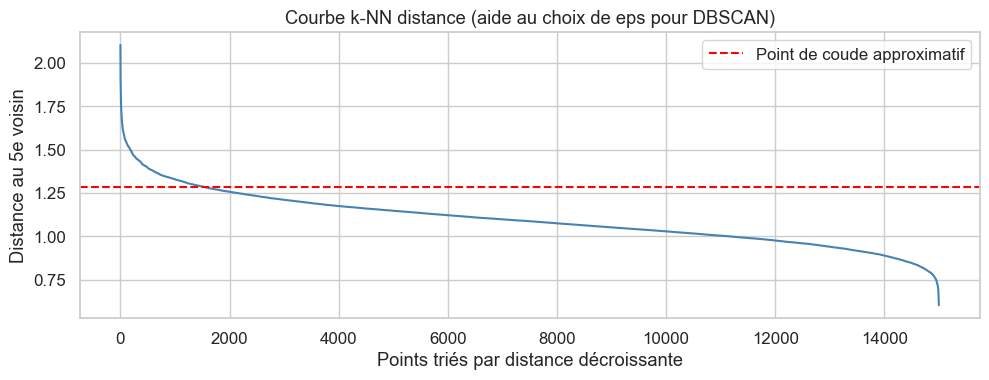

In [14]:
# Choix de eps via la courbe des distances k-nearest neighbors
from sklearn.neighbors import NearestNeighbors

k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
dist_sorted = np.sort(distances[:, k_nn-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted, lw=1.5, color='steelblue')
ax.set_xlabel('Points triés par distance décroissante')
ax.set_ylabel(f'Distance au {k_nn}e voisin')
ax.set_title('Courbe k-NN distance (aide au choix de eps pour DBSCAN)')
ax.axhline(dist_sorted[int(len(dist_sorted)*0.1)], color='red', linestyle='--', label='Point de coude approximatif')
ax.legend()
plt.tight_layout()
plt.show()

DBSCAN (eps=1.5, min_samples=50) :
  Clusters détectés : 1
  Points bruit (outliers) : 1325 (8.8%)

Répartition :
cluster_dbscan
-1     1325
 0    13675
Name: count, dtype: int64


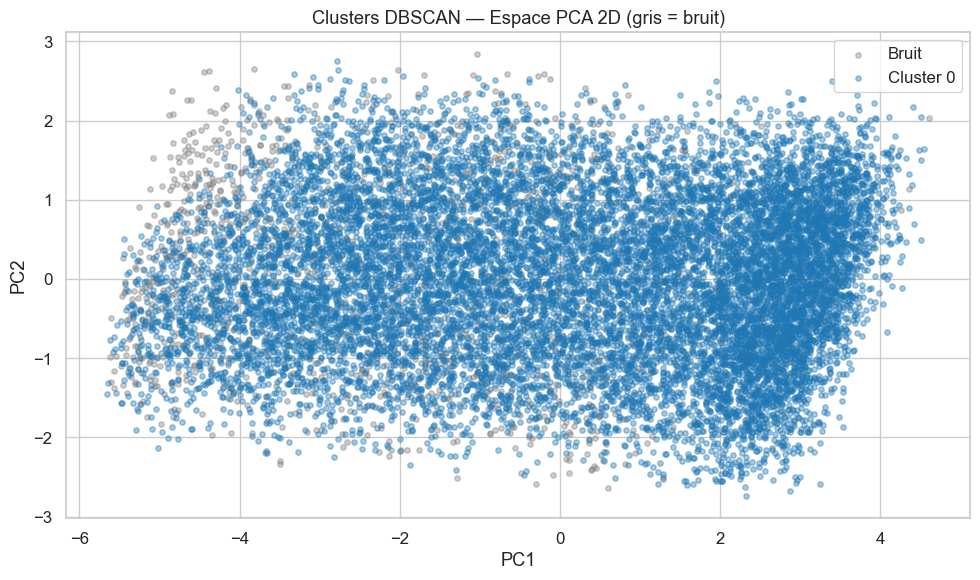

In [15]:
# DBSCAN
# Sur données standardisées — eps à ajuster selon la courbe k-NN
dbscan = DBSCAN(eps=1.5, min_samples=50, n_jobs=-1)
df_cluster['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_cluster['cluster_dbscan'])) - (1 if -1 in df_cluster['cluster_dbscan'].values else 0)
n_noise      = (df_cluster['cluster_dbscan'] == -1).sum()

print(f'DBSCAN (eps=1.5, min_samples=50) :')
print(f'  Clusters détectés : {n_clusters_db}')
print(f'  Points bruit (outliers) : {n_noise} ({n_noise/len(df_cluster)*100:.1f}%)')
print(f'\nRépartition :')
print(df_cluster['cluster_dbscan'].value_counts().sort_index())

# Visualisation DBSCAN dans l'espace PCA
fig, ax = plt.subplots(figsize=(10, 6))
dbscan_labels = df_cluster['cluster_dbscan'].values
unique_labels = sorted(set(dbscan_labels))

for lbl in unique_labels:
    mask = dbscan_labels == lbl
    color = 'gray' if lbl == -1 else sns.color_palette('tab10')[lbl % 10]
    label = 'Bruit' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label, alpha=0.4, s=15)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Clusters DBSCAN — Espace PCA 2D (gris = bruit)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparaison KMeans vs DBSCAN et nommage des profils

In [16]:
# Métriques de qualité de clustering
print('Métriques de qualité (hors bruit DBSCAN) :')

mask_no_noise = df_cluster['cluster_dbscan'] != -1

if mask_no_noise.sum() > 100 and len(set(df_cluster.loc[mask_no_noise, 'cluster_dbscan'])) > 1:
    sil_db = silhouette_score(X_scaled[mask_no_noise], df_cluster.loc[mask_no_noise, 'cluster_dbscan'], sample_size=2000)
else:
    sil_db = np.nan

sil_km = silhouette_score(X_scaled, df_cluster['cluster_kmeans'], sample_size=3000)

print(f'  KMeans (k={K_OPTIMAL})  — Silhouette : {sil_km:.4f}')
print(f'  DBSCAN             — Silhouette : {sil_db:.4f}  (sur points non-bruit)')

Métriques de qualité (hors bruit DBSCAN) :
  KMeans (k=4)  — Silhouette : 0.1442
  DBSCAN             — Silhouette : nan  (sur points non-bruit)


In [17]:
# Nommage interprétatif des clusters KMeans (à adapter selon vos résultats)
profile_sorted = profile.sort_values('stress_level')

print('Interprétation des clusters (basée sur les moyennes) :')
for k in range(K_OPTIMAL):
    row = profile.loc[k]
    print(f'\nCluster {k}:')
    print(f'  Temps écran moyen : {row["daily_screen_time_hours"]:.2f}h')
    print(f'  Sommeil moyen     : {row["sleep_duration_hours"]:.2f}h')
    print(f'  Stress moyen      : {row["stress_level"]:.2f}/10')
    print(f'  Fatigue mentale   : {row["mental_fatigue_score"]:.2f}/10')
    print(f'  Activité physique : {row["physical_activity_minutes"]:.0f} min')
    print(f'  Bien-être global  : {row["wellness_score"]:.2f}')
    # Label automatique
    if row['stress_level'] < 4 and row['sleep_duration_hours'] > 7:
        label = '→ Profil ÉQUILIBRÉ'
    elif row['stress_level'] > 7 and row['daily_screen_time_hours'] > 6:
        label = '→ Profil SUREXPOSÉ NUMÉRIQUE'
    elif row['physical_activity_minutes'] > 60:
        label = '→ Profil ACTIF'
    else:
        label = '→ Profil SÉDENTAIRE'
    print(f'  {label}')

Interprétation des clusters (basée sur les moyennes) :

Cluster 0:
  Temps écran moyen : 2.45h
  Sommeil moyen     : 6.53h
  Stress moyen      : 3.18/10
  Fatigue mentale   : 3.14/10
  Activité physique : 60 min
  Bien-être global  : 6.08
  → Profil ACTIF

Cluster 1:
  Temps écran moyen : 7.81h
  Sommeil moyen     : 6.50h
  Stress moyen      : 9.27/10
  Fatigue mentale   : 9.10/10
  Activité physique : 61 min
  Bien-être global  : -2.77
  → Profil SUREXPOSÉ NUMÉRIQUE

Cluster 2:
  Temps écran moyen : 7.85h
  Sommeil moyen     : 6.51h
  Stress moyen      : 9.67/10
  Fatigue mentale   : 9.41/10
  Activité physique : 58 min
  Bien-être global  : -4.37
  → Profil SUREXPOSÉ NUMÉRIQUE

Cluster 3:
  Temps écran moyen : 4.48h
  Sommeil moyen     : 6.49h
  Stress moyen      : 6.32/10
  Fatigue mentale   : 6.34/10
  Activité physique : 58 min
  Bien-être global  : 1.32
  → Profil SÉDENTAIRE
